# 2.8 Transformadas espectrales


## Introducción
En las geociencias, buena parte de los datos con los que tratamos — ondas sísmicas, mareas oceánicas, variaciones de presión atmosférica — llega en forma de series de tiempo. Estas señales suelen contener información en múltiples frecuencias, y un análisis simple en el dominio del tiempo puede ocultar rasgos importantes de los datos.

Los espectrogramas son herramientas útiles para analizar y visualizar el contenido de frecuencia de las series de tiempo. Un espectrograma representa la densidad espectral de una señal a medida que cambia en el tiempo. Es especialmente útil en aplicaciones geocientíficas donde las señales son no estacionarias, es decir, su contenido de frecuencia cambia con el tiempo. Algunos ejemplos:

* ***Sismología de terremotos***: donde las señales de baja y de alta frecuencia son relevantes en distintas etapas de un evento.
* ***Ciencias de la atmósfera***: donde patrones periódicos como las mareas y las ondas tienen componentes de frecuencia distintivas.
* ***Percepción remota***: donde distintos procesos, como las fluctuaciones de humedad del suelo, pueden exhibir frecuencias características a lo largo del tiempo.

**Por qué importan los espectrogramas**
* ***Análisis tiempo-frecuencia***: los espectrogramas muestran cómo evoluciona en el tiempo el contenido de frecuencia de una señal, lo que los hace adecuados para estudiar datos no estacionarios.
* ***Extracción de características***: los espectrogramas resaltan los eventos transitorios y los patrones de larga duración, útiles para detectar y caracterizar fenómenos geofísicos como sismos, deslizamientos de tierra u ondas atmosféricas.
* ***Análisis multiescala***: muchos procesos naturales operan en distintas escalas de tiempo. Los espectrogramas permiten visualizar y extraer características a través de esas escalas.
* ***Visualización***: ofrecen una visualización compacta e interpretable de series de tiempo complejas.

En esta sección transformamos los datos proyectándolos sobre una base de funciones. Las dos transformadas más usadas son la de **Fourier** y la de **ondículas** (*wavelets*).

**Advertencia.** Filtrar cualquier dato debe hacerse con cuidado. Los artefactos de filtrado pueden llevar a una malinterpretación completa. Trampas comunes:
* No todos los filtros preservan la causalidad: algunas señales pueden aparecer **antes de los eventos** y malinterpretarse como *precursores*.
* Filtrar sobre huecos en los datos introduce artefactos de alta frecuencia.
* Los efectos de borde al filtrar series de tiempo son difíciles de mitigar.

La lección cubre varios niveles y métodos para transformar los datos.

1. Transformadas de Fourier: 1D  [**Nivel 1**]
2. Transformadas de Fourier: 2D  [**Nivel 3**]
3. Espectrogramas [**Nivel 2**]
4. Transformadas de ondículas [**Nivel 3**]

🖥️ [**Diapositivas — Sesión 07 (mié 14 oct)**](https://geo-smart.github.io/mlgeo-book/slides/2026/lec07_statistics_spectra.html)

In [1]:
# Import modules for seismic data and feature extraction

import os

import numpy as np
import matplotlib.pyplot as plt
import scipy
import scipy.signal as signal

# seismic python toolbox
import obspy
import obspy.clients.fdsn.client as fdsn
from obspy import UTCDateTime

os.makedirs('data', exist_ok=True)

Primero descargamos los datos: sismogramas registrados en el Puget Sound para el sismo M8.2 de Chignik, Alaska, del 29 de julio de 2021. Consultamos el centro de datos FDSN con el cliente `IRIS`. Note que los servicios de datos de IRIS ahora los opera [EarthScope](https://www.earthscope.org/), pero el nombre de cliente `IRIS` sigue funcionando.

El código de canal `HHZ` denota un sismómetro de banda ancha de alta ganancia (H), muestreado a 100 muestras por segundo (H), componente vertical (Z). Es un canal de banda ancha: registra el movimiento del suelo en una banda de frecuencias amplia, no en una sola frecuencia.

También descargamos los metadatos de la estación (la respuesta instrumental) y removemos la respuesta con `remove_response(output="VEL")`. Esto convierte las cuentas crudas del digitalizador en velocidad del suelo en m/s, de modo que las amplitudes tienen unidades físicas.

In [2]:
# Download seismic data
network = 'UW'
station = 'RATT'
channel = 'HHZ'  # broadband high-gain vertical channel, 100 samples per second
Tstart = UTCDateTime(2021, 7, 29, 6, 15)
Tend = Tstart + 7200
fdsn_client = fdsn.Client('IRIS')  # client to query the EarthScope (formerly IRIS) DMC server

# download the station metadata, including the instrument response
inv = fdsn_client.get_stations(network=network, station=station, channel=channel,
                               starttime=Tstart - 7200, endtime=Tend, level='response')

# call to download the specific data: earthquake waveforms
Z = fdsn_client.get_waveforms(network=network, station=station, location='--', channel=channel,
                              starttime=Tstart, endtime=Tend)
# basic pre-processing: merge if there are gaps, detrend, taper,
# then remove the instrument response to convert digitizer counts to ground velocity (m/s).
Z.merge(); Z.detrend(type='linear'); Z[0].taper(max_percentage=0.05)
Z.remove_response(inventory=inv, output="VEL")

# call to download the specific data: noise waveforms (the two hours before the earthquake)
N = fdsn_client.get_waveforms(network=network, station=station, location='--', channel=channel,
                              starttime=Tstart - 7200, endtime=Tstart)
N.merge(); N.detrend(type='linear'); N[0].taper(max_percentage=0.05)
N.remove_response(inventory=inv, output="VEL")

/Users/marinedenolle/Dropbox/CLASSES/ESS490/curriculum-book/.pixi/envs/default/lib/python3.12/site-packages/obspy/clients/fdsn/client.py:251: ObsPyDeprecationWarning: IRIS is now EarthScope, please consider changing the FDSN client short URL to 'EARTHSCOPE'.
  warnings.warn(msg, ObsPyDeprecationWarning)


1 Trace(s) in Stream:
UW.RATT..HHZ | 2021-07-29T04:15:00.000000Z - 2021-07-29T06:14:59.990000Z | 100.0 Hz, 720000 samples

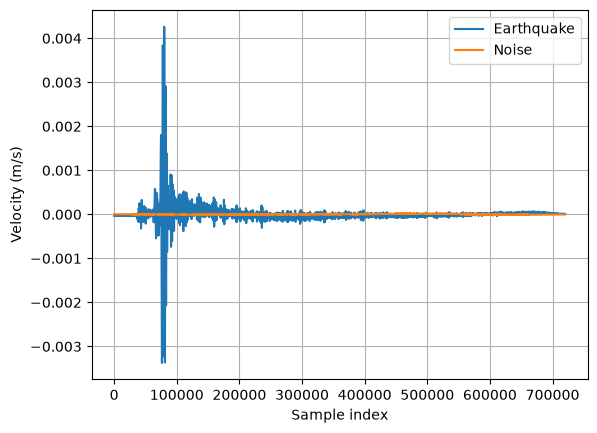

In [3]:
plt.plot(Z[0].data); plt.plot(N[0].data); plt.grid(True)
plt.ylabel('Velocity (m/s)'); plt.xlabel('Sample index')
plt.legend(['Earthquake', 'Noise'])


## 1. Transformadas de Fourier [**Nivel 1**]
Usamos el módulo [`scipy.fft`](https://docs.scipy.org/doc/scipy/reference/fft.html) para transformar las dos series de tiempo (sismo y ruido). El módulo más antiguo `scipy.fftpack` es heredado y ya no debe usarse.

La transformada de Fourier es una descomposición de la serie de tiempo sobre una base ortonormal de funciones coseno y seno. La transformada de Fourier de una serie de tiempo $f(t)$ (igual si la variable es el espacio $x$) es:

$\hat{F}(f) = \int_{-\infty}^\infty f(t) \exp^{-i2\pi ft} dt$

$\hat{F}(f)$ es el valor complejo de Fourier en la frecuencia $f$. La transformada de Fourier determina qué frecuencias dominan la serie de tiempo.


### 1.1 Nyquist
La transformada de Fourier que usamos en esta clase toma una serie de tiempo discreta de números reales. Si la serie abarca $T$ segundos con $N$ muestras regularmente espaciadas, el intervalo de muestreo es $dt = T/N$. La frecuencia más alta que puede resolverse en una serie de tiempo discreta, llamada frecuencia de Nyquist, está limitada por $dt$:

$F_{Nyq} = \frac{1}{2 dt}$

En la práctica, no se pueden restringir señales que varían más rápido que dos muestras de tiempo. Aquí $dt = 0.01$ s, así que $F_{Nyq} = 50$ Hz.

### 1.2 Incertidumbres
* La transformada de Fourier discreta produce una aproximación de la TF. Cuanto más corta la serie de tiempo, menos exacta la TF. Esto significa que la TF sobre ventanas de tiempo cortas es menos exacta.
* La TF supone (y requiere) la periodicidad de la serie, es decir, que la serie de tiempo finita/recortada se repetiría en el tiempo. Para forzarlo, aplicamos un **taper** (afinamiento gradual) a la serie de tiempo, de modo que el primer y el último punto sean iguales (a cero).

In [4]:
from scipy.fft import fft, ifft, fftfreq, next_fast_len

npts = Z[0].stats.npts

## FFT the signals
# pad up to a fast FFT length to speed up the FFT
Nfft = next_fast_len(int(Z[0].data.shape[0]))  # this will be an even number

freqVec = fftfreq(Nfft, d=Z[0].stats.delta)[:Nfft//2]

Z.taper(max_percentage=0.05)

Zhat = fft(Z[0].data, n=Nfft)

Consulte la documentación de ObsPy para conocer la función [taper](https://docs.obspy.org/master/packages/autogen/obspy.core.trace.Trace.taper.html#supported-methods).
Grafique los espectros de amplitud y de fase.

Text(0.5, 1.0, 'Distribution of the phase spectrum')

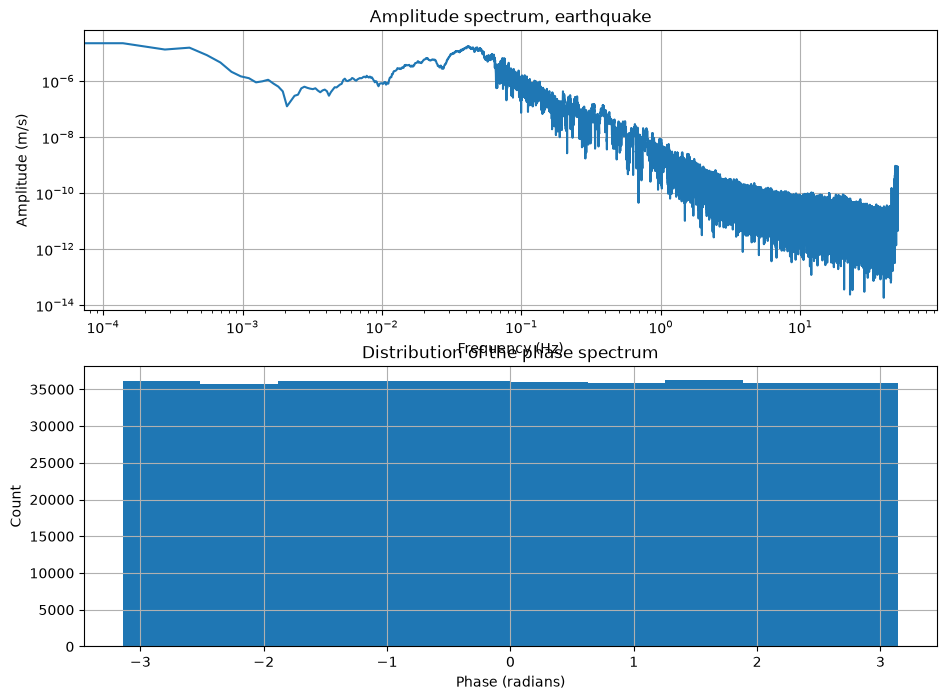

In [5]:
fig, ax = plt.subplots(2, 1, figsize=(11, 8))
ax[0].plot(freqVec, np.abs(Zhat[:Nfft//2])/Nfft)
ax[0].grid(True)
ax[0].set_xscale('log'); ax[0].set_yscale('log')
ax[0].set_xlabel('Frequency (Hz)'); ax[0].set_ylabel('Amplitude (m/s)')
ax[0].set_title('Amplitude spectrum, earthquake')

ax[1].hist(np.angle(Zhat[:Nfft//2]))
ax[1].grid(True)
ax[1].set_xlabel('Phase (radians)'); ax[1].set_ylabel('Count')
ax[1].set_title('Distribution of the phase spectrum')

Notará arriba que los valores de fase están distribuidos aleatoriamente entre $-\pi$ y $\pi$. Podemos comprobarlo mostrando la distribución de los espectros de fase y de amplitud.

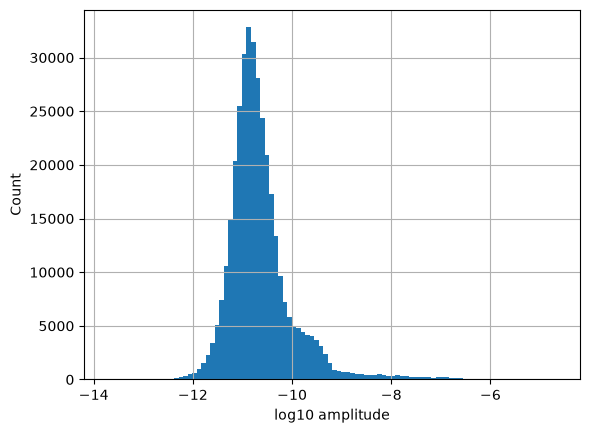

In [6]:
# your turn. Plot the histogram of the amplitude spectrum
plt.hist(np.log10(np.abs(Zhat[:Nfft//2])/Nfft), 100); plt.grid(True)
plt.xlabel('log10 amplitude'); plt.ylabel('Count')
plt.show()

También podemos analizar las características espectrales de la serie de tiempo de ruido. Abajo:
1. calcule la transformada de Fourier
2. grafique los espectros de fase y de amplitud
3. grafique la distribución de los valores de fase y de amplitud

In [7]:
# compute Fourier transform of the noise time series

npts1 = N[0].stats.npts
## FFT the signals
# pad up to a fast FFT length to speed up the FFT
Nfft1 = next_fast_len(int(N[0].data.shape[0]))  # this will be an even number
freqVec1 = fftfreq(Nfft1, d=N[0].stats.delta)[:Nfft1//2]

# taper the data to enforce periodicity
N.taper(max_percentage=0.05)

# Fourier transform
Nhat = fft(N[0].data, n=Nfft1)

Text(0, 0.5, 'Count')

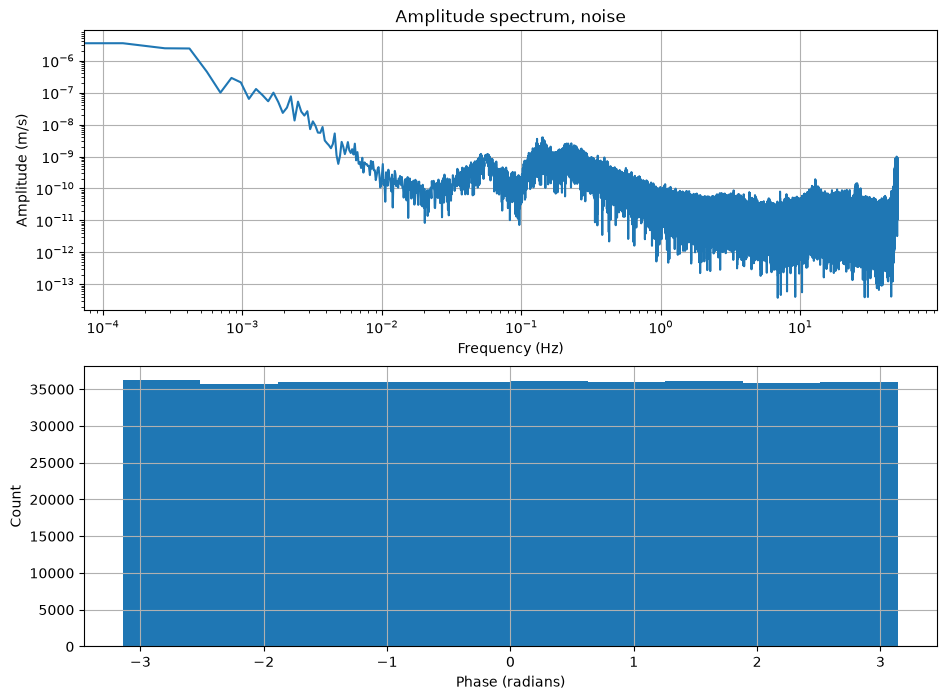

In [8]:
# plot the phase and amplitude spectra
fig, ax = plt.subplots(2, 1, figsize=(11, 8))
ax[0].plot(freqVec1, np.abs(Nhat[:Nfft1//2])/Nfft1)
ax[0].grid(True)
ax[0].set_xscale('log'); ax[0].set_yscale('log')
ax[0].set_xlabel('Frequency (Hz)'); ax[0].set_ylabel('Amplitude (m/s)')
ax[0].set_title('Amplitude spectrum, noise')
ax[1].hist(np.angle(Nhat[:Nfft1//2]))
ax[1].grid(True)
ax[1].set_xlabel('Phase (radians)'); ax[1].set_ylabel('Count')

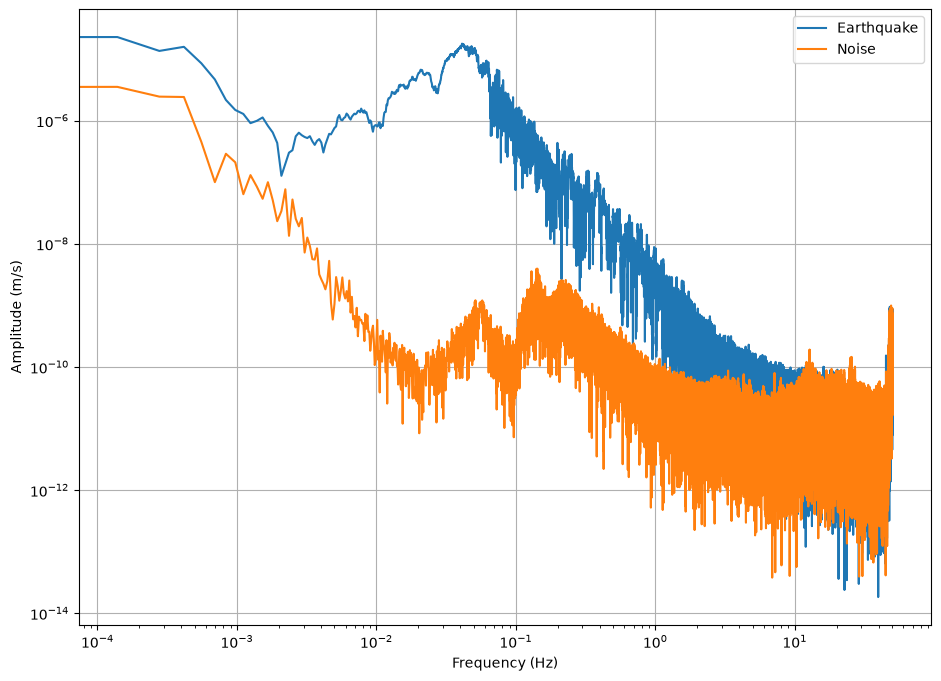

In [9]:
# Overlay the spectrum of the earthquake and the spectrum of the noise

fig, ax = plt.subplots(1, 1, figsize=(11, 8))
ax.plot(freqVec, np.abs(Zhat[:Nfft//2])/Nfft)
ax.plot(freqVec1, np.abs(Nhat[:Nfft1//2])/Nfft1)
ax.grid(True)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('Amplitude (m/s)')
ax.legend(['Earthquake', 'Noise'])

Superponga sus PDF (funciones de densidad de probabilidad).

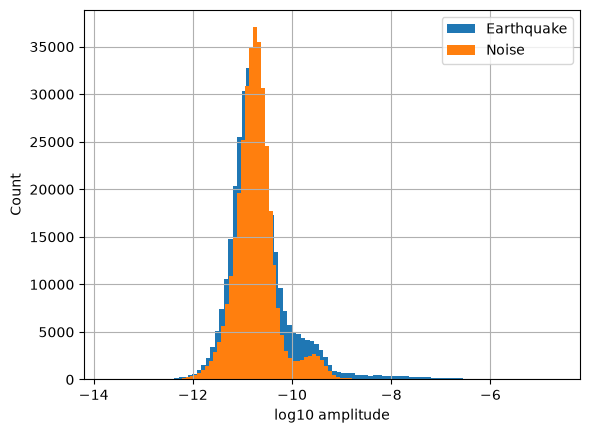

In [10]:
# your turn. Plot the histograms of the amplitude spectra
plt.hist(np.log10(np.abs(Zhat[:Nfft//2])/Nfft), 100)
plt.hist(np.log10(np.abs(Nhat[:Nfft1//2])/Nfft1), 100)
plt.grid(True)
plt.xlabel('log10 amplitude'); plt.ylabel('Count')
plt.legend(['Earthquake', 'Noise'])
plt.show()

Nota que sus diferencias estadísticas están en las colas de las distribuciones. Por lo tanto, métricas estadísticas como la ``mean`` (media) o la ``variance`` (varianza) pueden no ser discriminantes, pero la ``kurtosis`` (curtosis) podría serlo.

In [11]:
# print short float values
print(f"Skewness of earthquake {scipy.stats.skew(np.log10(np.abs(Zhat[:Nfft//2])))} and noise {scipy.stats.skew(np.log10(np.abs(Nhat[:Nfft1//2])))}")

print(f"Kurtosis of earthquake {scipy.stats.kurtosis(np.log10(np.abs(Zhat[:Nfft//2])))} and noise {scipy.stats.kurtosis(np.log10(np.abs(Nhat[:Nfft1//2])))}")

print(f"Mean of earthquake {np.mean(np.log10(np.abs(Zhat[:Nfft//2])))} and noise {np.mean(np.log10(np.abs(Nhat[:Nfft1//2])))}")

print(f"standard deviation of earthquake {np.std(np.log10(np.abs(Zhat[:Nfft//2])))} and noise {np.std(np.log10(np.abs(Nhat[:Nfft1//2])))}")

Skewness of earthquake 2.4536951625773393 and noise 0.7840246929880705
Kurtosis of earthquake 11.193100408198315 and noise 2.7513010817145336
Mean of earthquake -4.772491127799235 and noise -4.872561055684669
standard deviation of earthquake 0.7077083875872446 and noise 0.4345104292391202


## 2. Transformadas de Fourier 2D [**Nivel 3**]

La transformada de Fourier 2D se aplica a una matriz 2D. Primero aplica una transformada de Fourier 1D a cada fila de la matriz, y luego aplica una transformada de Fourier 1D a cada columna de la matriz intermedia.

Las transformadas de Fourier 2D dan los coeficientes de Fourier que dominan una imagen. Esto puede usarse para filtrar los datos. Otra aplicación es comprimir los datos conservando unos pocos coeficientes en lugar de almacenar la imagen completa.

Practicaremos sobre un campo sintético con aspecto de topografía. La topografía real tiene un espectro de número de onda «rojo»: la mayor parte de la potencia se concentra en las longitudes de onda largas (las cordilleras — piense en la Sierra Madre Occidental o en los Andes), con cada vez menos potencia en las longitudes de onda cortas (la rugosidad de pequeña escala). La amplitud espectral decae aproximadamente como una ley de potencias del número de onda $k$, $|\hat{F}(k)| \propto k^{-\beta}$. Podemos construir un terreno fractal así directamente en el dominio de Fourier: extraer fases aleatorias, escalar las amplitudes por $k^{-\beta}$ y aplicar la transformada inversa.

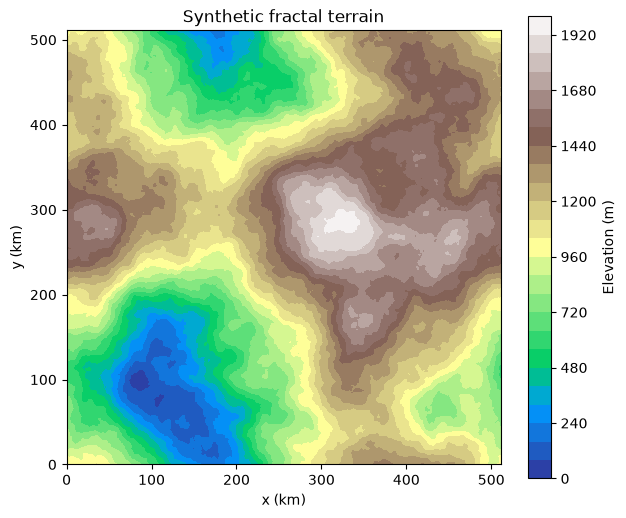

In [12]:
from scipy.fft import fft2, ifft2, fftshift
from scipy.fft import fftfreq as fftfreq2d

# build a synthetic fractal terrain with a power-law (red) wavenumber spectrum
rng = np.random.default_rng(42)

nx, ny = 512, 512      # grid size
dx = 1.0               # grid spacing in km
beta = 2.0             # spectral decay exponent: amplitude ~ k^-beta

# wavenumber grids (cycles per km)
kx = fftfreq2d(nx, d=dx)
ky = fftfreq2d(ny, d=dx)
KX, KY = np.meshgrid(kx, ky, indexing='ij')
K = np.sqrt(KX**2 + KY**2)
K[0, 0] = np.inf  # avoid division by zero at the zero wavenumber (mean)

# random phases on a white-noise field, amplitudes scaled by k^-beta
white = rng.standard_normal((nx, ny))
shaped = fft2(white) * K**(-beta)
elevation = np.real(ifft2(shaped))

# rescale to a plausible elevation range in meters
elevation = 2000 * (elevation - elevation.min()) / (elevation.max() - elevation.min())

# spatial coordinate vectors in km
xkm = np.arange(nx) * dx
ykm = np.arange(ny) * dx

plt.figure(figsize=(7, 6))
plt.contourf(xkm, ykm, elevation.T, 30, cmap='terrain')
plt.colorbar(label='Elevation (m)')
plt.xlabel('x (km)'); plt.ylabel('y (km)')
plt.title('Synthetic fractal terrain')
plt.axis('scaled')
plt.show()

Considere ``elevation`` como un conjunto de datos 2D. Podemos realizar una transformada 2D, que da un espectro en las dimensiones espaciales. Los ejes de la imagen transformada son números de onda (ciclos por km). Usamos ``fftshift`` para colocar el número de onda cero en el centro de la imagen.

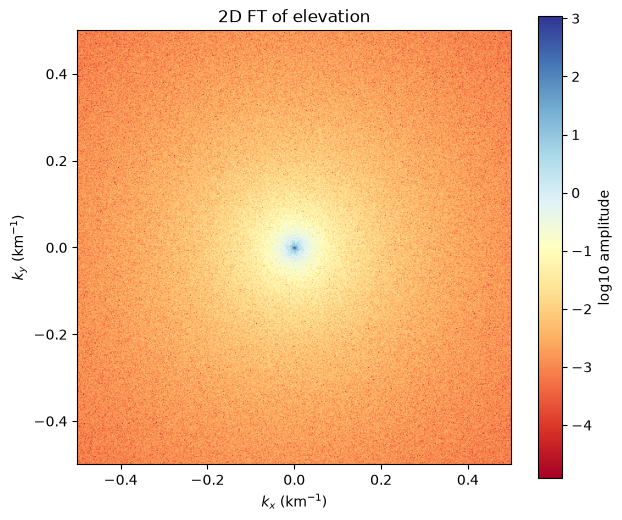

In [13]:
Zel = fft2(elevation)

kmax = 1 / (2 * dx)  # Nyquist wavenumber in cycles per km

plt.figure(figsize=(7, 6))
plt.imshow(fftshift(np.log10(np.abs(Zel) / Zel.size)), cmap='RdYlBu',
           extent=[-kmax, kmax, -kmax, kmax])
plt.colorbar(label='log10 amplitude')
plt.xlabel('$k_x$ (km$^{-1}$)'); plt.ylabel('$k_y$ (km$^{-1}$)')
plt.title('2D FT of elevation')
plt.show()

La energía se concentra cerca del centro del gráfico (números de onda bajos, longitudes de onda largas), tal como se diseñó. Ahora comprimiremos la imagen conservando solo los coeficientes de Fourier más grandes.

In [14]:
# Sort the Fourier coefficient amplitudes
Zsort = np.sort(np.abs(Zel).reshape(-1))
print(len(Zsort))
print(Zsort.shape)

262144
(262144,)


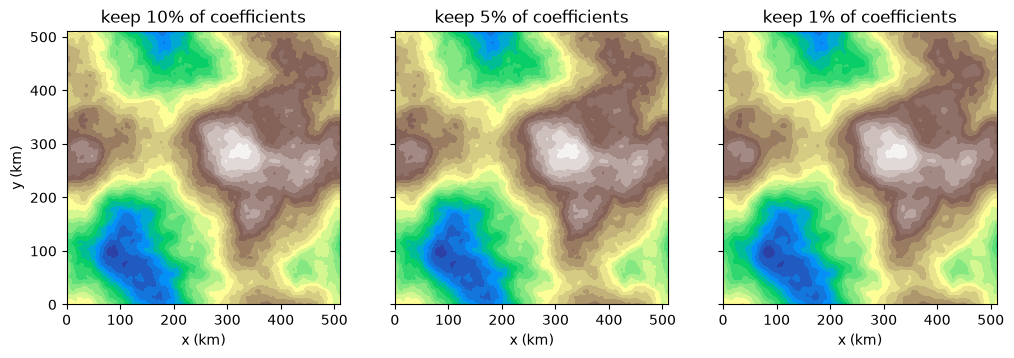

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for i, keep in enumerate((0.1, 0.05, 0.01)):
    thresh = Zsort[int(np.floor((1 - keep) * len(Zsort)))]
    ind = np.abs(Zel) > thresh
    Atlow = Zel * ind  # zero out the small coefficients
    Alow = np.real(ifft2(Atlow))
    ax[i].contourf(xkm, ykm, Alow.T, 30, cmap='terrain')
    ax[i].set_title(f'keep {keep*100:.0f}% of coefficients')
    ax[i].axis('scaled')
    ax[i].set_xlabel('x (km)')
ax[0].set_ylabel('y (km)')
plt.show()

Ahora comparamos el conjunto de datos 2D original con los datos comprimidos por Fourier. Conservar el 1 % de los coeficientes es una razón de compresión de 100:1, y la reconstrucción aún captura la estructura de gran escala del terreno. El precio es la pérdida de la rugosidad de pequeña escala, que vive en los coeficientes de número de onda alto descartados.

We are keeping 1.00% of the Fourier coefficients, a compression ratio of 100:1
Relative reconstruction error: 0.006


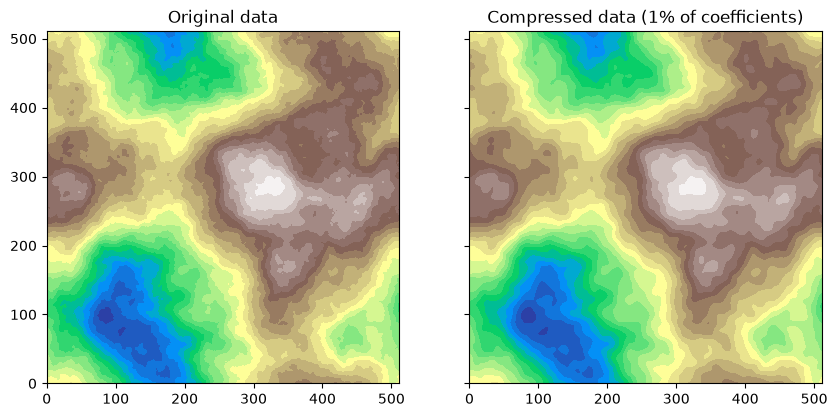

In [16]:
keep = 0.01
thresh = Zsort[int(np.floor((1 - keep) * len(Zsort)))]
ind = np.abs(Zel) > thresh
Atlow = Zel * ind  # zero out the small coefficients
print("We are keeping %.2f%% of the Fourier coefficients, a compression ratio of %d:1" % (keep*100, int(1/keep)))
Alow = np.real(ifft2(Atlow))

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
ax[0].contourf(xkm, ykm, elevation.T, 30, cmap='terrain'); ax[0].set_title('Original data')
ax[0].axis('scaled')
ax[1].contourf(xkm, ykm, Alow.T, 30, cmap='terrain'); ax[1].set_title('Compressed data (1% of coefficients)')
ax[1].axis('scaled')

# quantify the reconstruction error
rel_err = np.linalg.norm(elevation - Alow) / np.linalg.norm(elevation)
print(f"Relative reconstruction error: {rel_err:.3f}")

## 3. Espectrogramas [**Nivel 2**]

En problemas dependientes del tiempo y multiescala, puede ser interesante extraer características de los datos a partir de la transformada de Fourier de tiempo corto (STFT, *short time Fourier transform*).

La STFT es una transformada de Fourier aplicada a ventanas cortas (traslapadas) para resolver las frecuencias en distintos momentos de la serie.

(0.1, 40)

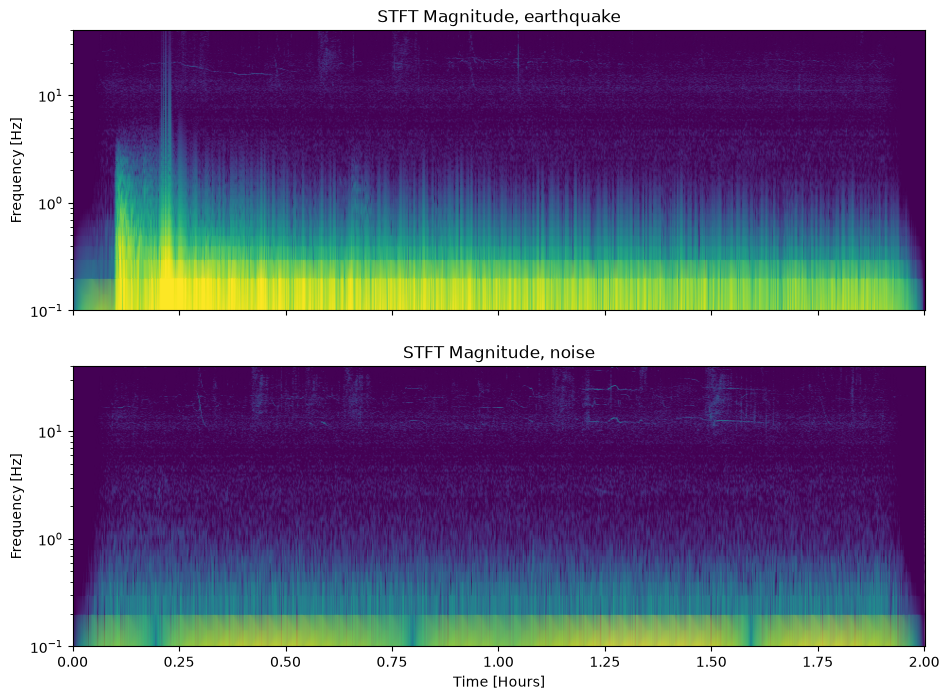

In [17]:
from scipy.signal import stft

fs = Z[0].stats.sampling_rate
nperseg = 1000
z = np.asarray(Z[0].data)
f, t, Zxx = stft(z, fs=fs, nperseg=nperseg, noverlap=200)
fig, ax = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
logZ = np.log10(np.abs(Zxx) + 1e-20)
ax[0].pcolormesh(t/3600, f, logZ, vmin=np.percentile(logZ, 50), vmax=np.percentile(logZ, 99.9), shading='gouraud')
ax[0].set_title('STFT Magnitude, earthquake')
ax[0].set_ylabel('Frequency [Hz]')
ax[0].set_yscale('log'); ax[0].set_ylim(0.1, 40)

n = np.asarray(N[0].data)
fn, tn, Nxx = stft(n, fs=fs, nperseg=nperseg, noverlap=200)
logN = np.log10(np.abs(Nxx) + 1e-20)
ax[1].pcolormesh(tn/3600, fn, logN, vmin=np.percentile(logN, 50), vmax=np.percentile(logN, 99.9), shading='gouraud')
ax[1].set_title('STFT Magnitude, noise')
ax[1].set_ylabel('Frequency [Hz]')
ax[1].set_xlabel('Time [Hours]'); ax[1].set_yscale('log'); ax[1].set_ylim(0.1, 40)

El espectrograma ``Zxx`` es una transformada de los datos originales. Es común usar espectrogramas como entrada de redes neuronales, en forma de arreglos 2D.

In [18]:
Zxx.shape

(501, 902)

## 4. Transformada continua de ondículas [**Nivel 3**]

### Introducción
La **transformada continua de ondículas** (CWT, *Continuous Wavelet Transform*) es una herramienta importante en el análisis de datos geocientíficos, en particular para el análisis tiempo-frecuencia de señales no estacionarias. Como el espectrograma, la CWT permite ver cómo varía en el tiempo el contenido de frecuencia de una señal. Sin embargo, la CWT ofrece mejor resolución en las distintas frecuencias, lo que la hace más adecuada para analizar señales con cambios de frecuencia transitorios o localizados.

La **transformada de ondículas** descompone una señal en versiones escaladas y desplazadas de una función oscilante pequeña conocida como la **ondícula** (*wavelet*). Esto hace que la CWT sea idónea para las aplicaciones geocientíficas, donde muchos fenómenos, como los sismos, las erupciones volcánicas y los patrones meteorológicos, pueden manifestarse en distintas escalas y frecuencias.

![Fourier and Wavelet](../img/Wavelet-Out1.jpeg)

**Figura:** funciones de base de Fourier y de ondículas. Imagen de este [artículo](https://ataspinar.com/2018/12/21/a-guide-for-using-the-wavelet-transform-in-machine-learning/).

Existen muchas familias canónicas de ondículas. La diferencia entre familias es típicamente su forma, su compacidad y su suavidad. Por lo general, se elige una familia para la serie de tiempo específica. Las ondículas tienen energía finita y media cero.

![Wavelets](../img/wavelet_families.png)

**Figura**: familias de funciones de base de ondículas. Imagen de este [artículo](https://ataspinar.com/2018/12/21/a-guide-for-using-the-wavelet-transform-in-machine-learning/)

La transformada de ondículas es:

$\hat{F}(a,b) = \frac{1}{\sqrt{a}} \int_{-\infty}^\infty f(t) \bar{\Psi} (\frac{t-b}{a}) dt$

donde $\bar{\Psi}$ es la ondícula madre escalada por un factor $a$ y trasladada/desplazada por $b$. En la transformada continua, $a$ y $b$ toman valores continuos. La *transformada discreta de ondículas* es la transformada de ondículas realizada sobre un número finito de escalas y desplazamientos.

La representación tiempo-escala de una serie de tiempo es un *escalograma*. Las *escalas* pueden convertirse en pseudofrecuencias: si $f_c$ es la frecuencia central de la ondícula, la escala es $a$ y el intervalo de muestreo es $dt$, entonces la pseudofrecuencia es $f_a = f_c/(a \, dt)$.

### Por qué importan las transformadas continuas de ondículas
- **Análisis multirresolución**: la CWT captura tanto las tendencias de baja frecuencia y larga duración como los rasgos de alta frecuencia y corta duración. Esto es particularmente valioso en las geociencias, donde los procesos ocurren en distintas escalas temporales y espaciales.
- **Datos no estacionarios**: muchas señales geocientíficas son no estacionarias, es decir, sus propiedades estadísticas cambian con el tiempo. La CWT revela esas componentes de frecuencia variables en el tiempo.
- **Detección de rasgos locales**: la CWT es idónea para identificar eventos localizados, como ondas sísmicas, deslizamientos de tierra o perturbaciones atmosféricas, al analizar cómo cambia la señal tanto en tiempo como en frecuencia.
- **Mejor resolución tiempo-frecuencia**: la transformada de ondículas ofrece una localización en tiempo y frecuencia más precisa que métodos como la transformada de Fourier o el espectrograma, sobre todo para eventos de corta vida.

### Uso en sismología
En los datos sísmicos, los distintos tipos de ondas sísmicas (ondas P, ondas S y ondas superficiales) ocurren en frecuencias y duraciones distintas. Al aplicar la CWT, los sismólogos pueden detectar esas distintas fases de onda y sus tiempos de llegada precisos, que importan para la caracterización de los sismos.

### Ejemplo en Python: transformada continua de ondículas de datos sísmicos

Usamos el paquete [PyWavelets](https://pywavelets.readthedocs.io/) (`pywt`). Las funciones más antiguas `scipy.signal.cwt` y `scipy.signal.morlet2` fueron removidas de SciPy, así que `pywt` es ahora la herramienta estándar. Elegimos la ondícula de Morlet compleja `'cmor1.5-1.0'` (ancho de banda 1.5, frecuencia central 1.0), una elección común para datos sísmicos porque su forma compleja da tanto la amplitud como la fase.

`pywt.cwt` trabaja en escalas. Elegimos las frecuencias que queremos resolver (0.1 a 40 Hz, espaciadas logarítmicamente) y luego las convertimos en escalas con la relación $a = f_c / (f \, dt)$, que es lo que calcula `pywt.frequency2scale`. Para mantener liviano el cálculo, aplicamos la CWT a los primeros 20 minutos del registro del sismo, que contienen las ondas P, S y superficiales.

In [19]:
import pywt

fs = Z[0].stats.sampling_rate
dt = 1 / fs

# analyze the first 20 minutes of the earthquake record
nsel = int(1200 * fs)
zsel = z[:nsel]
tsel = np.arange(nsel) / fs

# choose the frequencies to resolve, then convert them to scales
wavelet = 'cmor1.5-1.0'
freqs_target = np.logspace(np.log10(0.1), np.log10(40), 100)
scales = pywt.frequency2scale(wavelet, freqs_target * dt)  # scales for the target frequencies

# compute the CWT; frequencies returned in Hz thanks to sampling_period
coefficients, frequencies = pywt.cwt(zsel, scales, wavelet, sampling_period=dt, method='fft')
print(coefficients.shape, frequencies.min(), frequencies.max())

(100, 120000) 0.1 39.99999999999999


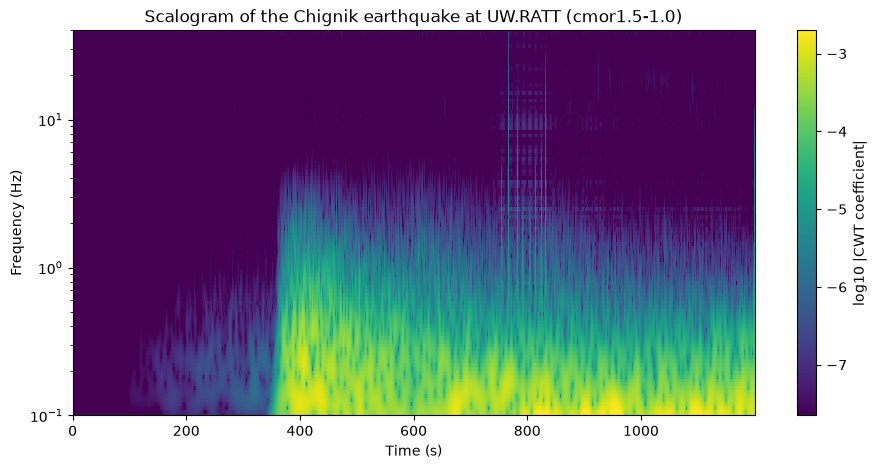

In [20]:
# plot the scalogram with a frequency axis in Hz
logC = np.log10(np.abs(coefficients) + 1e-20)
plt.figure(figsize=(11, 5))
plt.pcolormesh(tsel, frequencies, logC, cmap='viridis',
               vmin=np.percentile(logC, 50), vmax=np.percentile(logC, 99.9), shading='auto')
plt.yscale('log')
plt.ylim(frequencies.min(), frequencies.max())
plt.colorbar(label='log10 |CWT coefficient|')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.title('Scalogram of the Chignik earthquake at UW.RATT (cmor1.5-1.0)')
plt.show()

El escalograma muestra la onda P llegando primero con energía de alta frecuencia, seguida por la onda S y las ondas superficiales de periodo largo por debajo de 0.1-0.5 Hz. Compare esto con el espectrograma STFT de arriba: la transformada de ondículas resuelve mejor las ondas superficiales de baja frecuencia porque su ventana de tiempo se adapta a cada frecuencia.

#### Ventajas de la CWT en las geociencias:
- **Detección de eventos localizados en el tiempo**: la CWT identifica eventos geofísicos de corta vida, como la llegada de las ondas sísmicas durante un sismo.
- **Fenómenos multiescala**: procesos naturales como la actividad tectónica y las mareas oceánicas operan en un rango amplio de escalas temporales y espaciales. La CWT puede analizar señales de esos procesos usando un rango amplio de escalas.
- **Detección de bordes**: la transformada de ondículas es particularmente buena para detectar cambios o discontinuidades en las señales, como el inicio abrupto de las ondas sísmicas o las fronteras entre distintas capas geofísicas.

#### Casos de uso en las geociencias:
- **Alerta sísmica temprana**: al aplicar la CWT, los geocientíficos pueden detectar con más exactitud la primera llegada de las ondas sísmicas, que importa para los sistemas de alerta temprana como el SASMEX mexicano.
- **Detección de deslizamientos de tierra**: la CWT ayuda a identificar las señales de alta frecuencia indicativas de deslizamientos, ya que estos eventos suelen caracterizarse por ráfagas cortas de energía.
- **Tremor volcánico**: la CWT puede usarse para analizar las señales de tremor volcánico — como las que registran las redes de monitoreo del Popocatépetl —, que suelen ser complejas y exhibir rasgos tanto de corta como de larga duración.

#### Conclusión
La transformada continua de ondículas (CWT) es una herramienta útil para el análisis tiempo-frecuencia en las geociencias. Su capacidad de resolver señales a través de distintas escalas y frecuencias la hace idónea para estudiar procesos no estacionarios. Bibliotecas de Python como `pywt`, `obspy` y `matplotlib` permiten a los geocientíficos aplicar la CWT a sus datos y extraer conocimiento de fenómenos geofísicos complejos.

Las transformadas tiempo-frecuencia consumen tiempo de cómputo en un flujo de trabajo. Comparemos el costo de la CWT y de la STFT sobre el mismo segmento de 20 minutos.

In [21]:
import time

tic = time.perf_counter()
pywt.cwt(zsel, scales, wavelet, sampling_period=dt, method='fft')
toc = time.perf_counter()
print(f"CWT (100 scales, 20 min of data): {toc - tic:.2f} s")

tic = time.perf_counter()
stft(zsel, fs=fs, nperseg=nperseg, noverlap=200)
toc = time.perf_counter()
print(f"STFT (same data): {toc - tic:.3f} s")

CWT (100 scales, 20 min of data): 0.46 s
STFT (same data): 0.001 s


La STFT es mucho más barata que la CWT. De estas transformadas podemos extraer características estadísticas similares.